# SVD Landscape Fine-tuning
Run each cell in order. Make sure you have an **A100 GPU** selected:
> Runtime → Change runtime type → A100 GPU

In [ ]:
# ── 1. Check GPU ────────────────────────────────────────────────────────────
!nvidia-smi

Sat Mar 14 16:16:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             51W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ── 2. Install dependencies ──────────────────────────────────────────────────
!pip install -q \
    yt-dlp \
    opencv-python-headless \
    diffusers[torch] \
    transformers \
    accelerate \
    peft \
    imageio[ffmpeg] \
    tqdm \
    Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.4/182.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.8 MB/s eta 0:00:00


In [ ]:
# ── 3. (Optional) Mount Google Drive to persist data/checkpoints ─────────────
from google.colab import drive
drive.mount('/content/drive')

# Change these if you want to save elsewhere
DATA_DIR   = '/content/drive/MyDrive/svd_landscape/data'
CKPT_DIR   = '/content/drive/MyDrive/svd_landscape/checkpoints'

Mounted at /content/drive


In [ ]:
# ── 4. Upload scripts ────────────────────────────────────────────────────────
# Upload make_dataset_svd.py and train_svd_lora.py using the file panel on the left,
# or run this cell to download them if hosted somewhere.
# (Replace URLs with your actual hosted script URLs if needed)

# If you uploaded them manually, just verify they're here:
!ln -s /content/drive/MyDrive/SVD/make_dataset_svd.py
!ln -s /content/drive/MyDrive/SVD/train_svd_lora.py

In [ ]:
# ── 5. Extract dataset ───────────────────────────────────────────────────────

!python /content/make_dataset_svd.py \
    --url   'https://www.youtube.com/watch?v=AKeUssuu3Is' \
    --out   $DATA_DIR \
    --clip_len 14 \
    --fps      7 \
    --size     512 \
    --interval 4.0 \
    --max_clips 2000

[youtube] Extracting URL: https://www.youtube.com/watch?v=AKeUssuu3Is
[youtube] AKeUssuu3Is: Downloading webpage
[youtube] AKeUssuu3Is: Downloading android vr player API JSON
[info] AKeUssuu3Is: Downloading 1 format(s): 136
[download] /content/tmp_landscape.mp4 has already been downloaded
[download] 100% of    3.64GiB
Opening local video file...
Clips extracted: 0clips [00:00, ?clips/s]Video FPS: 24.0 | Frame stride: 3 | Clip interval: 96 frames
Clips extracted: 2000clips [17:53,  1.62clips/s]
Reached max_clips=2000. Stopping.
Clips extracted: 2000clips [17:53,  1.86clips/s]

Done. 2000 clips saved to /content/drive/MyDrive/svd_landscape/data
Each clip: 14 frames @ 7 fps → 2.0s of motion


Total clips: 2000


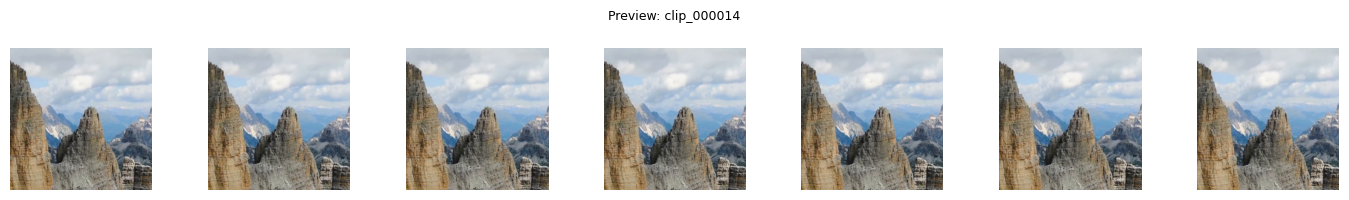

In [64]:
# ── 6. Verify dataset ────────────────────────────────────────────────────────
import os
clips = [d for d in os.listdir(DATA_DIR) if d.startswith('clip_')]
print(f'Total clips: {len(clips)}')

# Preview first clip
from PIL import Image
import matplotlib.pyplot as plt

first_clip = sorted(clips)[14]
frames = sorted(os.listdir(os.path.join(DATA_DIR, first_clip)))
fig, axes = plt.subplots(1, min(7, len(frames)), figsize=(14, 2))
for ax, fname in zip(axes, frames[:7]):
    ax.imshow(Image.open(os.path.join(DATA_DIR, first_clip, fname)))
    ax.axis('off')
plt.suptitle(f'Preview: {first_clip}', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── 7. Login to HuggingFace (needed to download SVD weights) ─────────────────
# Get your token at https://huggingface.co/settings/tokens
from huggingface_hub import login
login()  # will prompt for token

In [34]:
# ── 8. Train ─────────────────────────────────────────────────────────────────
# Expected time on A100: ~1.5–2.5h for 2000 clips × 3 epochs
# Watch for 'New best saved' lines — that means it's learning.

!python /content/train_svd_lora.py \
    --data_dir         $DATA_DIR \
    --output_dir       $CKPT_DIR \
    --clip_len         14 \
    --size             512 \
    --epochs           3 \
    --batch_size       1 \
    --lr               1e-4 \
    --lora_rank        16 \
    --fps_id           7 \
    --motion_bucket_id 127

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[17:04:35] Device: cuda | dtype: torch.bfloat16
[17:04:35] Loading SVD pipeline...
Loading pipeline components...:  40% 2/5 [00:00<00:00, 13.10it/s]
Loading weights:   0% 0/520 [00:00<?, ?it/s]
Loading weights:   0% 1/520 [00:00<00:00, 12052.60it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 1/520 [00:00<00:00, 2003.97it/s, Materializing param=vision_model.embeddings.class_embedding] 
Loading weights:   0% 2/520 [00:00<00:00, 2401.55it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   0% 2/520 [00:00<00:00, 2075.36it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   1% 3/520 

In [65]:
import shutil
import os

# Prendre la première frame du premier clip
first_clip = sorted(os.listdir('/content/drive/MyDrive/svd_landscape/data'))[14]
first_frame = f'/content/drive/MyDrive/svd_landscape/data/{first_clip}/frame_000.jpg'
shutil.copy(first_frame, '/content/test_landscape.jpg')
print(f"Copié depuis {first_frame}")

Copié depuis /content/drive/MyDrive/svd_landscape/data/clip_000014/frame_000.jpg


In [74]:
with open('/content/train_svd_lora.py', 'r') as f:
    code = f.read()

code = code.replace(
    'pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_dir)',
    '# pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_dir)  # désactivé'
)

with open('/content/train_svd_lora.py', 'w') as f:
    f.write(code)

In [75]:
# ── 9. Quick inference test ──────────────────────────────────────────────────
# Upload a landscape image to /content/test_landscape.jpg first
import glob
lora_best = glob.glob(f'{CKPT_DIR}/run_*/lora_best')[0]
print(f'Using LoRA from: {lora_best}')

!python /content/train_svd_lora.py \
    --infer \
    --lora_dir   $lora_best \
    --image_path /content/test_landscape.jpg

Using LoRA from: /content/drive/MyDrive/svd_landscape/checkpoints/run_20260314_170440/lora_best
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline for inference...
Loading pipeline components...:   0% 0/5 [00:00<?, ?it/s]
Loading weights:   0% 0/520 [00:00<?, ?it/s]
Loading weights:   0% 1/520 [00:00<00:00, 13025.79it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 1/520 [00:00<00:00, 2959.99it/s, Materializing param=vision_model.embeddings.class_embedding] 
Loading weights:   0% 2/520 [00:00<00:00, 2250.16it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   0% 2/520 [00:00<00:00, 1481.82it/s, Materializing param=vision_model.embeddings.patch_embeddi

In [76]:
# ── 10. Display output video ──────────────────────────────────────────────────
from IPython.display import Video
Video('output.mp4', embed=True)